<a href="https://colab.research.google.com/github/physicalcodescooker/DampedPendulum/blob/main/RK4_solution_DDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

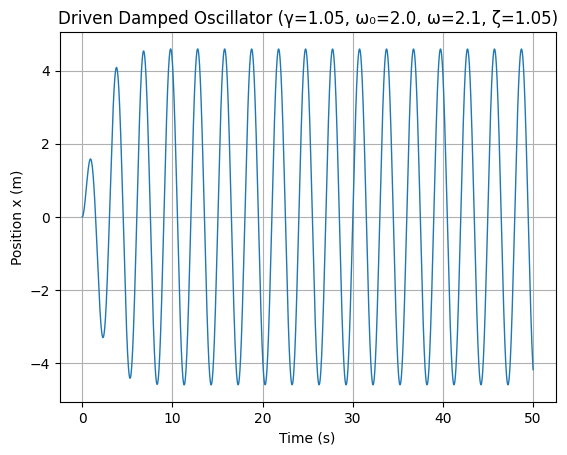

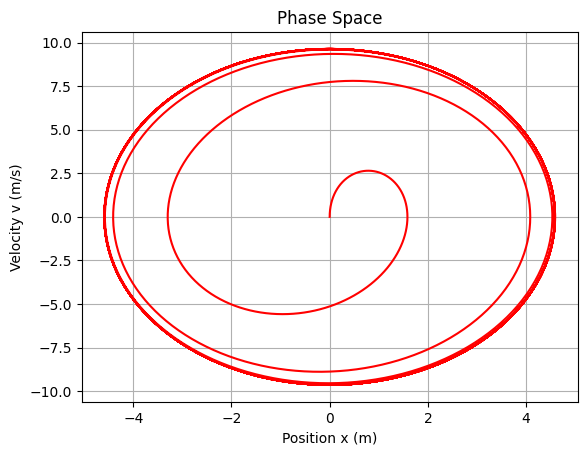

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rk4_step(f, y, t, dt): #[f => derivative function: dy/dt = f(y,t), y => array like state vector, t => time, dt => time step]

#The step in the integrator
    k1 = dt * f(y, t)
    k2 = dt * f(y + 0.5*k1, t + 0.5*dt)
    k3 = dt * f(y + 0.5*k2, t + 0.5*dt)
    k4 = dt * f(y + k3, t + dt)

    return y + (k1 + 2*k2 + 2*k3 + k4) / 6


def driven_damped_oscillator(y, t, gamma, omega0, omega, zeta, g=9.8):

    """Equations of motion for driven damped harmonic oscillator:
    From: ẍ + γẋ + ω₀²x = (F₀/m)cos(ωt)
    With: ζ = F₀/(mg) a dimensionless constant that describes the strength of the driving force.
    Therefore: ẍ + γẋ + ω₀²x = ζg·cos(ωt) """

   #Independant variables of the function
    x, v = y

    # First derivative of the function: dx/dt = v
    dxdt = v

    # dv/dt = ẍ = -γẋ - ω₀²x + ζg·cos(ωt)
    dvdt = -gamma*v - omega0**2 * x + zeta*g * np.cos(omega*t)

    return np.array([dxdt, dvdt])


def integrate_oscillator(x0, v0, t_span, dt, gamma, omega0, omega, zeta):

    t_start, t_end = t_span
    n_steps = int((t_end - t_start) / dt)

    # Initialize arrays
    t = np.linspace(t_start, t_end, n_steps + 1)
    x = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)

    # Set initial conditions
    x[0] = x0
    v[0] = v0
    y = np.array([x0, v0])

    # Define derivative function with fixed parameters
    def f(y, t):
        return driven_damped_oscillator(y, t, gamma, omega0, omega, zeta)

    # Integrate using RK4
    for i in range(n_steps):
        y = rk4_step(f, y, t[i], dt)
        x[i+1] = y[0]
        v[i+1] = y[1]

    return t, x, v


# Example: Underdamped oscillator with weak driving
if __name__ == "__main__":
    # Physical parameters
    gamma = 1.05     # Damping coefficient
    omega0 = 2.0     # Natural frequency
    omega = 2.1  # Driving frequency
    zeta = 1.05      # Driving strength

    # Initial conditions
    x0 = 0.0         # Initial position (m)
    v0 = 0.0         # Initial velocity (m/s)

    # Integration parameters
    t_span = (0, 50)  # Time range (s)
    dt = 0.01         # Time step (s)

    # Integrate
    t, x, v = integrate_oscillator(x0, v0, t_span, dt, gamma, omega0, omega, zeta)

    # Position vs time
    plt.plot(t, x,linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel('Position x (m)')
    plt.title(f'Driven Damped Oscillator (γ={gamma}, ω₀={omega0}, ω={omega}, ζ={zeta})')
    plt.grid(True)
    plt.show()

    # Phase space
    plt.plot(x, v, color='red')
    plt.xlabel('Position x (m)')
    plt.ylabel('Velocity v (m/s)')
    plt.title('Phase Space')
    plt.grid(True)

    plt.show()